In [57]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [58]:
X, y = make_circles(n_samples = 1000, random_state = 42, noise = 0.03)

In [59]:
df = pd.DataFrame(X, y)
X.shape, y.shape

((1000, 2), (1000,))

In [60]:
X_reduced = PCA(n_components = 2).fit_transform(X)

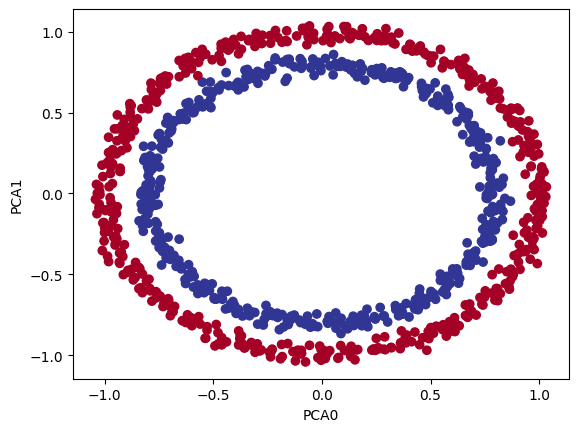

In [61]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("PCA0")
plt.ylabel("PCA1")
plt.show()

In [62]:
## Turning ndarray(numpy array) into torch.tensor

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [63]:
# Train,Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [65]:
X_train.shape

torch.Size([800, 2])

In [67]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [72]:
class MultiLayerClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()

        ## Linear Layer (multi)
        self.layer_1 = torch.nn.Linear(
            in_features = 2, out_features = 5,
        )

        self.layer_2 = torch.nn.Linear(
            in_features = 5, out_features = 1
        )

        ## Method 2 (sequential layer)
        # self.seq_layer = torch.nn.Sequential(
        #     torch.nn.Linear(
        #         in_features = 2, out_features = 5
        #    ),
        #     torch.nn.Linear(
        #         in_features = 5, out_features = 1
        #     )
        # )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x))

In [77]:
model = MultiLayerClassifier().to(device)
model

MultiLayerClassifier(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [76]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.3837, -0.6151],
                      [-0.0592, -0.1614],
                      [-0.1723,  0.0491],
                      [-0.6984,  0.4609],
                      [-0.6031,  0.5337]], device='mps:0')),
             ('layer_1.bias',
              tensor([-0.4400, -0.6844, -0.6882, -0.5082,  0.0996], device='mps:0')),
             ('layer_2.weight',
              tensor([[ 0.4172, -0.3926, -0.1716, -0.1793,  0.3617]], device='mps:0')),
             ('layer_2.bias', tensor([-0.0823], device='mps:0'))])

In [82]:
with torch.inference_mode():
    y_pred = model(X_test.to(device))

len(y_pred), y_pred.shape, y_pred.dim, y_pred[:10]

(200,
 torch.Size([200, 1]),
 <function Tensor.dim()>,
 tensor([[ 0.0077],
         [ 0.0444],
         [ 0.0024],
         [ 0.0088],
         [ 0.1466],
         [ 0.1678],
         [ 0.1569],
         [ 0.1861],
         [-0.0037],
         [ 0.0484]], device='mps:0'))

In [83]:
len(X_test), X_test.shape, X_test.dim, X_test[:10]

(200,
 torch.Size([200, 2]),
 <function Tensor.dim()>,
 tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]))

In [81]:
X.shape, y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

/var/folders/4k/m7f5dtm96j744jvsqr8rndw80000gn/T/ipykernel_15820/168213779.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device))


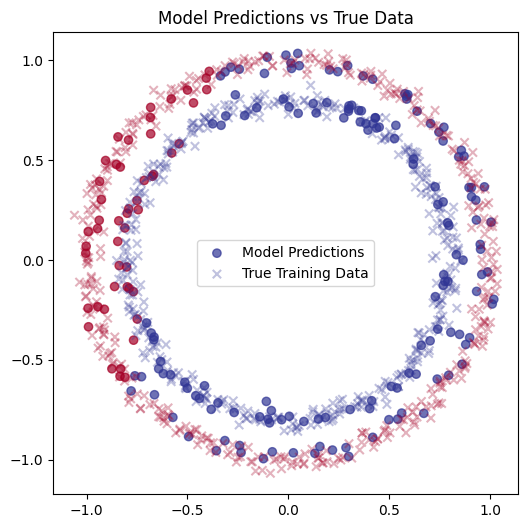

In [90]:
with torch.inference_mode():
    y_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device))
    y_pred = torch.round(torch.sigmoid(y_logits)).cpu().numpy().squeeze()

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap=plt.cm.RdYlBu, label="Model Predictions", alpha=0.7)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, label="True Training Data", alpha=0.3, marker="x")
plt.legend()
plt.title("Model Predictions vs True Data")
plt.show()